In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('data/Training.xlsx', parse_dates=['Completion Date', 'Match Activation Date'])

In [4]:
df.head()

,Match ID 18Char,Completion Date,Match Support Contact Notes,Stage,Little ID,Big ID,Big County,Big Age,Big Occupation,Big: Military,...,Little Contact: Interest Finder - Career,Little Contact: Interest Finder - Personality,Little Contact: Interest Finder - Three Wishes,Little Gender,Little Participant: Race/Ethnicity,Little Birthdate,Little Mailing Address Census Block Group,Big Home Census Block Group,Big Employer/School Census Block Group,Match Length
0,a1v2J0000028pRvQAI,2017-11-30,Question: Activities: Answer: See ms...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
1,a1v2J0000028pRvQAI,2017-10-31,Question: Activities: Answer: See MS...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
2,a1v2J0000028pRvQAI,2017-12-01,Question: Activities: Answer: Match ...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
3,a1v2J0000028pRvQAI,2017-05-29,Question: Activities: Answer: Msc as...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
4,a1v2J0000028pRvQAI,2017-04-30,Question: Activities: Answer: Msc as...,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0


In [5]:
# df_static contains only one row for each match without the time dependent data from each match
df_static = df.drop(['Completion Date', 'Match Support Contact Notes' ], axis=1)
df_static = df_static.drop_duplicates()
df_static = df_static[df_static['Match Length'].notna()]
df_static.head()

,Match ID 18Char,Stage,Little ID,Big ID,Big County,Big Age,Big Occupation,Big: Military,Big Approved Date,Big Level of Education,...,Little Contact: Interest Finder - Career,Little Contact: Interest Finder - Personality,Little Contact: Interest Finder - Three Wishes,Little Gender,Little Participant: Race/Ethnicity,Little Birthdate,Little Mailing Address Census Block Group,Big Home Census Block Group,Big Employer/School Census Block Group,Match Length
0,a1v2J0000028pRvQAI,Closed,0032J00003PLe29QAD,0032J00003PhDOI,Hennepin,40,Unemployed,NaN,NaT,Masters Degree,...,NaN,NaN,NaN,Female,Black or African American,2004-01-01,2.705303e+11,2.705302e+11,NaN,9.0
10,a1v2J000002uR0JQAU,Closed,0032J00003PfZ6OQAV,0032J00003PgoV1,Washington,65,Tech: Research/Design,NaN,2018-04-11,NaN,...,NaN,NaN,NaN,Female,Black or African American; White or Caucasian,2006-06-01,2.716307e+11,2.716307e+11,NaN,46.1
30,a1v2J0000027NsOQAU,Closed,0032J00003PLeoRQAT,0032J00003Ph0MT,Ramsey,45,Military,NaN,NaT,Bachelors Degree,...,NaN,NaN,NaN,Male,Black or African American; White or Caucasian,2007-01-01,2.700305e+11,2.712304e+11,NaN,6.2
36,a1v2J0000027dtOQAQ,Active,0032J00003PLeoRQAT,0032J00003Ph14N,Hennepin,61,Finance: Banking,NaN,2018-01-02,NaN,...,NaN,NaN,NaN,Male,Black or African American; White or Caucasian,2007-01-01,2.700305e+11,NaN,NaN,85.6
72,a1v2J0000028enKQAQ,Closed,0032J00003PfZ6QQAV,0032J00003Ph14j,Ramsey,29,Human Services: Non-Profit,NaN,2018-03-12,Bachelors Degree,...,NaN,NaN,NaN,Female,Hispanic,2005-01-01,2.716307e+11,2.705311e+11,NaN,28.3


## Response Variables: Match Length, Closure Reason

### Q1: Analyze distribution of response variables

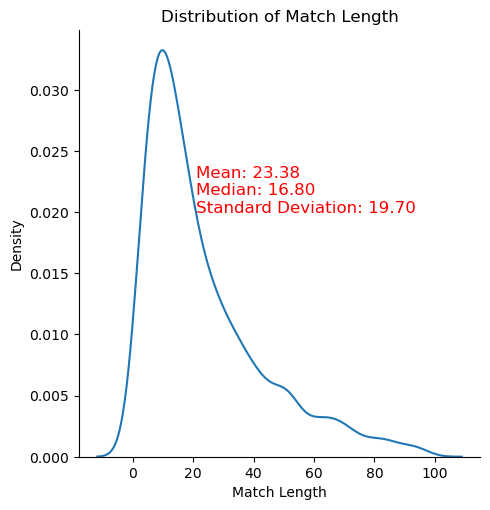

In [6]:
sns.displot(data=df_static, x='Match Length', kind='kde')
mean_match = df_static['Match Length'].mean()
median_match = df_static['Match Length'].median()
std_match = df_static['Match Length'].std()

s = f"Mean: {mean_match:.2f}\nMedian: {median_match:.2f}\nStandard Deviation: {std_match:.2f}"
plt.text(x=21, y=0.02, s=s, fontsize=12, color='red')
plt.title("Distribution of Match Length")
plt.show()

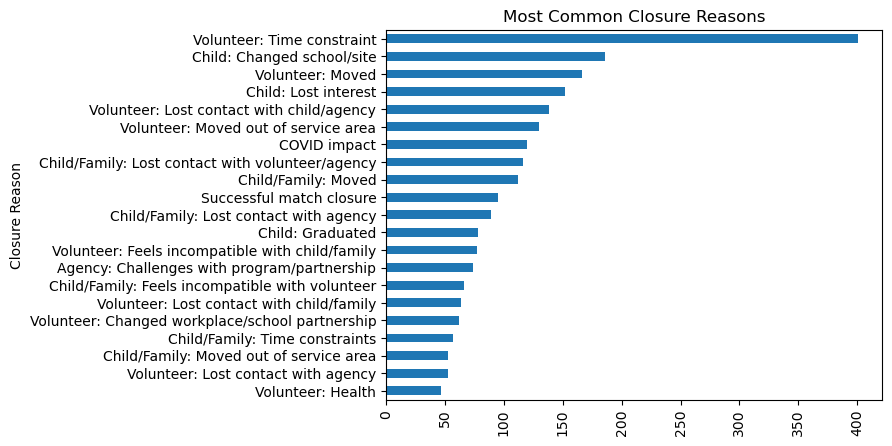

In [7]:
X = df_static[df_static['Closure Reason'].notna()]['Closure Reason'].value_counts().sort_values()
X[X>40].plot(kind='barh')
plt.xticks(rotation=90)
plt.title("Most Common Closure Reasons")
plt.show()

### Q1: Change of Response Variables with Program type

In [8]:
df_static[df_static['Program'].notna()]['Program'].value_counts()

Program
General Community                          1727
Virtual Match                               443
School-Based Program                        326
NAZ Zip Code                                 97
General Site                                 83
St Thomas/Four Seasons                       71
NAZ Match                                    56
BSW-Cargill                                  55
Grad Coach-Henry High School                 49
BSW-General Mills                            47
BSW-Carlson                                  41
Macalester/Dayton's Bluff                    39
YIP 2018                                     34
GRU Match                                    33
YIP 2019                                     32
Sports Buddies Cohorts 1/2 - 2023-24         31
BSW-Comcast                                  16
YIP 2016                                     13
Grad Coach-Edison High School                11
Weaver Elementary-Maplewood PD                9
STEM Cohort 2025                

Plotting the match length distribution of the top 9 programs by enrollment count

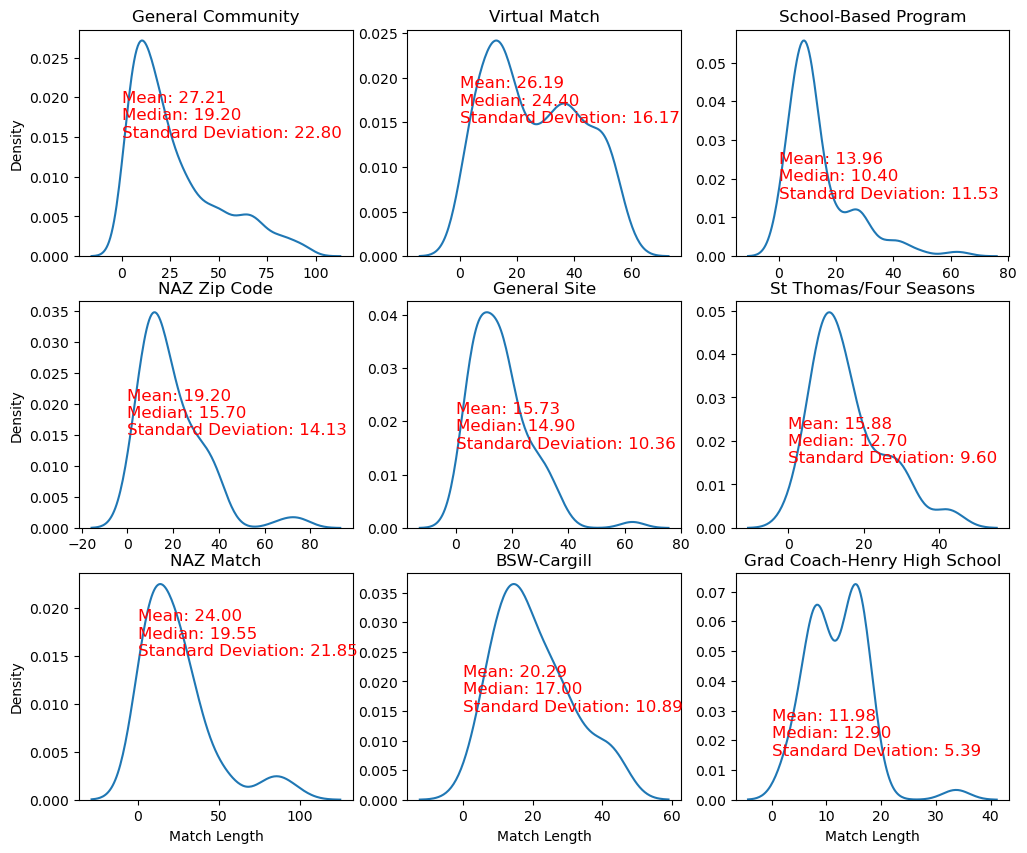

In [52]:
fig, ax = plt.subplots(3,3, figsize=(12,10))
top_programs = df_static[df_static['Program'].notna()]['Program'].value_counts().index[:9].to_list()

for i in range(3):
    for j in range(3):
        p = top_programs.pop(0)
        sns.kdeplot(data=df_static[df_static['Program'] == p], x='Match Length', ax=ax[i, j])
        mean_match = df_static[df_static['Program'] == p]['Match Length'].mean()
        median_match = df_static[df_static['Program'] == p]['Match Length'].median()
        std_match = df_static[df_static['Program'] == p]['Match Length'].std()

        s = f"Mean: {mean_match:.2f}\nMedian: {median_match:.2f}\nStandard Deviation: {std_match:.2f}"
        ax[i, j].text(x=0, y=0.015, s=s, fontsize=12, color='red')
        if i in [0, 1]:
            ax[i,j].set_xlabel(None)
        if j in [1, 2]:
            ax[i, j].set_ylabel(None)
        ax[i, j].set_title(f'{p}')
plt.show()